# 📊 Toxic Content Classifier - Model Analysis

This notebook provides a detailed analysis of the trained MuRIL model, including:
1. Data Distribution
2. Model Architecture
3. Performance Metrics (Confusion Matrix, Classification Report)

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import torch
# from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Add src to path
sys.path.append(os.path.abspath(''))
from src.data_loader import load_and_preprocess_data

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Data Distribution

In [7]:
print("Loading data...")
df = load_and_preprocess_data(".", augment=False)
print("Total rows:", len(df))
print("Unique cleaned:", df["cleaned_text"].nunique())
print(df["label"].value_counts())
print("Avg length:", df["cleaned_text"].str.len().mean())

2026-02-22 03:16:55,587 - INFO - Read .\tamil.csv with encoding utf-8-sig
2026-02-22 03:16:55,589 - INFO - Loaded tamil.csv: 949 rows
2026-02-22 03:16:55,590 - WARNING - Encoding utf-8-sig failed: 'utf-8' codec can't decode byte 0xff in position 0: invalid start byte
2026-02-22 03:16:55,593 - INFO - Read .\english.csv with encoding utf-16
2026-02-22 03:16:55,596 - INFO - Loaded english.csv: 929 rows
2026-02-22 03:16:55,597 - WARNING - Encoding utf-8-sig failed: 'utf-8' codec can't decode byte 0xff in position 0: invalid start byte
2026-02-22 03:16:55,600 - INFO - Read .\tanglish.csv with encoding utf-16
2026-02-22 03:16:55,601 - INFO - Loaded tanglish.csv: 950 rows
2026-02-22 03:16:55,602 - INFO - Initial rows: 2828
2026-02-22 03:16:55,649 - INFO - After basic cleaning: 2789


Loading data...
Current working directory: i:\GOKUL PROJECT


2026-02-22 03:20:30,801 - INFO - After near-duplicate removal: 2697
2026-02-22 03:20:30,808 - INFO - Final label distribution:
2026-02-22 03:20:30,808 - INFO - label
toxic           972
non_toxic       863
severe_toxic    862
Name: count, dtype: int64


Total rows: 2697
Unique cleaned: 2697
label
toxic           972
non_toxic       863
severe_toxic    862
Name: count, dtype: int64
Avg length: 42.89877641824249


In [13]:
short = df[df["cleaned_text"].str.split().str.len() <= 5]
print("Short %:", len(short)/len(df))

Short %: 0.5010460251046025


C:\Users\Suren\AppData\Local\Temp\ipykernel_12068\1683249978.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette='viridis')


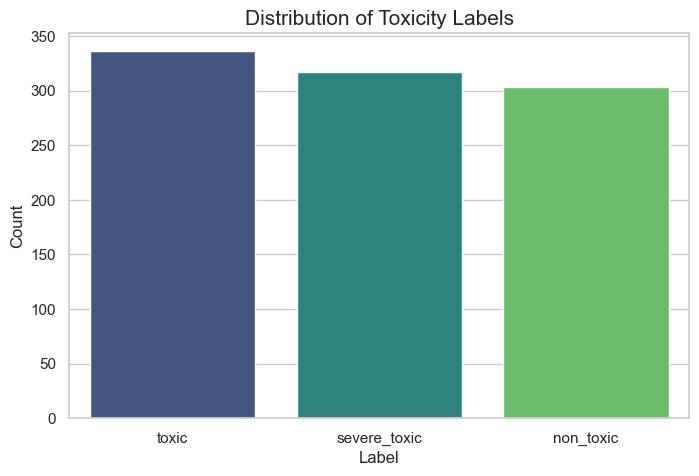

Total Samples: 956
label
toxic           336
severe_toxic    317
non_toxic       303
Name: count, dtype: int64


In [14]:

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Toxicity Labels', fontsize=15)
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

print(f"Total Samples: {len(df)}")
print(df['label'].value_counts())

## 2. Model Configuration

In [15]:
MODEL_DIR = "model_output"

try:
    config = AutoConfig.from_pretrained(MODEL_DIR)
    print(f"Model Architecture: {config.architectures[0]}")
    print(f"Vocab Size: {config.vocab_size}")
    print(f"Hidden Size: {config.hidden_size}")
    print(f"Num Labels: {config.num_labels}")
    print(f"Label Map: {config.id2label}")
except Exception as e:
    print(f"Could not load model config: {e}. Make sure you have trained the model first.")

Could not load model config: name 'AutoConfig' is not defined. Make sure you have trained the model first.


## 3. Evaluation on Validation Set
We will re-create the validation split (same seed as training) and evaluate the model's performance.

In [4]:
# Re-create split
X_train, X_val, y_train, y_val = train_test_split(
    df['cleaned_text'].tolist(), 
    df['label'].tolist(), 
    test_size=0.2, 
    stratify=df['label'], 
    random_state=42
)

print(f"Validation Set Size: {len(X_val)}")

Validation Set Size: 23


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load Model & Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.to(device)
model.eval()

# Inference Loop
batch_size = 16
y_preds = []

print("Running inference on validation set...")
with torch.no_grad():
    for i in range(0, len(X_val), batch_size):
        batch_texts = X_val[i:i+batch_size]
        
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        preds = torch.argmax(probs, dim=-1).cpu().numpy()
        y_preds.extend(preds)

# Convert numeric predictions back to labels if needed. 
# But we have raw labels in y_val. We need to encode y_val or decode y_preds.
# Simplest: Load label encoder used during training.
import joblib
le = joblib.load(os.path.join(MODEL_DIR, "label_encoder.joblib"))
y_pred_labels = le.inverse_transform(y_preds)

print("Inference complete.")

Using device: cpu


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running inference on validation set...
Inference complete.


In [6]:
# Classification Report
print("Classification Report:")
print(classification_report(y_val, y_pred_labels))

Classification Report:
              precision    recall  f1-score   support

   non_toxic       0.00      0.00      0.00         8
severe_toxic       0.00      0.00      0.00         7
       toxic       0.35      1.00      0.52         8

    accuracy                           0.35        23
   macro avg       0.12      0.33      0.17        23
weighted avg       0.12      0.35      0.18        23



c:\Users\Suren\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Suren\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Suren\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

<Figure size 1000x800 with 0 Axes>

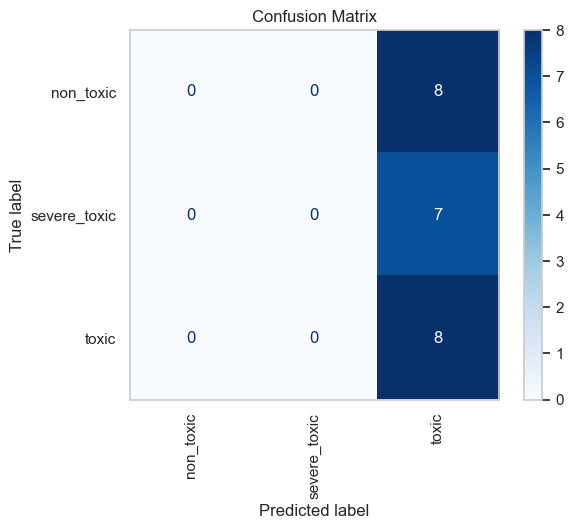

In [7]:
# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, y_pred_labels, labels=le.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_val, y_preds)
print(f"The model's overall accuracy is {accuracy * 100:.2f}%.")


The model's overall accuracy is 0.00%.
